# Mini-Projeto — Análise Exploratória da Base Varejo

**Autor:** Ednelson Rocha da Silva  
**Turma:** Analise_de_Dados_T6  
**Ferramenta:** Jupyter Notebook no VS Code

Este notebook documenta uma análise exploratória reproduzível da `Base Varejo.csv`. Cada linha representa **um item comprado**, enquanto `CO_ID` identifica a compra e pode aparecer em várias linhas.

## Resumo

- A origem possui **830.000 linhas** e **10 colunas úteis**; quatro campos excedentes totalmente vazios são descartados.
- Foram encontradas **96.553 duplicatas exatas** e **3.650 categorias ausentes ou `#N/D`**.
- Após a limpeza, o gênero **F** concentra **382.427 itens** e ALIMENTOS lidera com **384.197 itens**.
- Outubro de 2021 é o mês de maior volume, com **28.575 itens**.
- Entre 1.000 clientes, o número médio de filhos é **1,136**, a mediana e a moda são **0**.
- A base não possui preço ou valor; portanto, este trabalho mede volume de itens e compras, não faturamento.

## 1. Contexto e método

### Premissas importantes

1. Uma linha é um item; uma compra é o conjunto de linhas com o mesmo `CO_ID`.
2. Uma categoria ausente é imputada como `NAO_INFORMADA`, pois remover a linha apagaria um item real.
3. Duplicatas **exatas** são tratadas como repetição de ingestão, conforme a atividade. Sem ID de linha ou quantidade, essa hipótese deve ser validada com o responsável pela fonte em um projeto real.
4. As estatísticas de filhos usam um registro por cliente para impedir que clientes com mais itens tenham peso artificialmente maior.

## 2. Configuração

In [1]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda valor: f"{valor:,.2f}")

PASTA_PROJETO = Path.cwd()
if not (PASTA_PROJETO / "Base Varejo.csv").exists():
    # Permite executar pelo VS Code quando a pasta atual não acompanha o notebook.
    PASTA_PROJETO = Path(".").resolve()
ARQUIVO_ENTRADA = PASTA_PROJETO / "Base Varejo.csv"
PASTA_SAIDAS = PASTA_PROJETO / "saidas"
PASTA_SAIDAS.mkdir(exist_ok=True)

print("Base:", ARQUIVO_ENTRADA)
print("Existe:", ARQUIVO_ENTRADA.exists())

Base: d:\Mini_Projeto_SCTEC\MINI_PROJETO\MiniProjeto_Ednelson_Rocha_da_Silva_Analise_de_Dados_T6\Base Varejo.csv
Existe: True


## 3. Sprint 1 — Importação e compreensão da base

In [2]:
def padronizar_nome_coluna(nome):
    return re.sub(r"[^A-Z0-9_]+", "_", str(nome).strip().upper()).strip("_")

df_bruto = pd.read_csv(
    ARQUIVO_ENTRADA,
    sep=";",
    encoding="utf-8-sig",
    dtype="string",
    low_memory=False,
)
df_bruto.columns = [padronizar_nome_coluna(c) for c in df_bruto.columns]

# O CSV possui quatro colunas extras completamente vazias após PR_NOME.
colunas_extras_vazias = df_bruto.columns[df_bruto.isna().all()].tolist()
df_bruto = df_bruto.dropna(axis=1, how="all")

print(f"Registros: {len(df_bruto):,}")
print(f"Colunas úteis: {len(df_bruto.columns)}")
print("Colunas extras vazias removidas:", colunas_extras_vazias)
display(pd.DataFrame({"coluna": df_bruto.columns, "tipo_original": df_bruto.dtypes.astype(str)}))
display(df_bruto.head())

Registros: 830,000
Colunas úteis: 10
Colunas extras vazias removidas: ['UNNAMED_10', 'UNNAMED_11', 'UNNAMED_12', 'UNNAMED_13']


,coluna,tipo_original
DATA,DATA,string
CO_ID,CO_ID,string
CL_ID,CL_ID,string
CL_GENERO,CL_GENERO,string
CL_EC,CL_EC,string
CL_FHL,CL_FHL,string
CL_SEG,CL_SEG,string
PR_ID,PR_ID,string
PR_CAT,PR_CAT,string
PR_NOME,PR_NOME,string


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO


## 4. Diagnóstico de qualidade

In [3]:
categoria_normalizada = df_bruto["PR_CAT"].fillna("").str.strip().str.upper()
categorias_invalidas = categoria_normalizada.isin(["", "#N/D", "N/A", "NA"])
datas_teste = pd.to_datetime(df_bruto["DATA"], format="%d/%m/%Y", errors="coerce")

diagnostico = pd.DataFrame({
    "metrica": ["linhas", "duplicatas_exatas", "categorias_ausentes_ou_sentinela", "datas_invalidas"],
    "valor": [len(df_bruto), df_bruto.duplicated().sum(), categorias_invalidas.sum(), datas_teste.isna().sum()],
})
display(diagnostico)

nulos = df_bruto.isna().sum().rename("nulos").to_frame()
nulos["percentual"] = nulos["nulos"].div(len(df_bruto)).mul(100)
display(nulos)

,metrica,valor
0,linhas,830000
1,duplicatas_exatas,96553
2,categorias_ausentes_ou_sentinela,3650
3,datas_invalidas,0


,nulos,percentual
DATA,0,0.00
CO_ID,0,0.00
CL_ID,0,0.00
CL_GENERO,0,0.00
CL_EC,0,0.00
CL_FHL,0,0.00
CL_SEG,0,0.00
PR_ID,0,0.00
PR_CAT,0,0.00
PR_NOME,0,0.00


### Interpretação do diagnóstico

Os nulos nativos são zero nas dez colunas úteis, mas isso não significa completude perfeita: `#N/D` é um **valor sentinela** e precisa ser convertido. As duplicatas exatas são o maior risco para contagens. As datas seguem integralmente o padrão brasileiro esperado.

## 5. Sprints 2 e 3 — Tipos, nulos e duplicatas

In [4]:
df_limpo = df_bruto.copy()

for coluna in ["CL_GENERO", "CL_SEG", "PR_CAT", "PR_NOME"]:
    df_limpo[coluna] = df_limpo[coluna].str.strip().str.upper()

df_limpo["PR_CAT"] = (
    df_limpo["PR_CAT"]
    .replace({"": pd.NA, "#N/D": pd.NA, "N/A": pd.NA, "NA": pd.NA})
    .fillna("NAO_INFORMADA")
)
df_limpo["DATA"] = pd.to_datetime(df_limpo["DATA"], format="%d/%m/%Y", errors="coerce")

for coluna in ["CO_ID", "CL_ID", "CL_EC", "CL_FHL", "PR_ID"]:
    df_limpo[coluna] = pd.to_numeric(df_limpo[coluna], errors="coerce").astype("Int64")

linhas_antes = len(df_limpo)
df_limpo = df_limpo.drop_duplicates()
duplicatas_removidas = linhas_antes - len(df_limpo)

essenciais = ["DATA", "CO_ID", "CL_ID", "PR_ID", "PR_NOME"]
linhas_antes_essenciais = len(df_limpo)
df_limpo = df_limpo.dropna(subset=essenciais)
linhas_essenciais_removidas = linhas_antes_essenciais - len(df_limpo)

filhos_negativos = df_limpo["CL_FHL"].notna() & (df_limpo["CL_FHL"] < 0)
df_limpo.loc[filhos_negativos, "CL_FHL"] = pd.NA

print(f"Duplicatas removidas: {duplicatas_removidas:,}")
print(f"Linhas sem chaves essenciais removidas: {linhas_essenciais_removidas:,}")
print(f"Registros após limpeza: {len(df_limpo):,}")
display(pd.DataFrame({"coluna": df_limpo.columns, "tipo_limpo": df_limpo.dtypes.astype(str)}))

Duplicatas removidas: 96,553
Linhas sem chaves essenciais removidas: 0
Registros após limpeza: 733,447


,coluna,tipo_limpo
DATA,DATA,datetime64[ns]
CO_ID,CO_ID,Int64
CL_ID,CL_ID,Int64
CL_GENERO,CL_GENERO,string
CL_EC,CL_EC,Int64
CL_FHL,CL_FHL,Int64
CL_SEG,CL_SEG,string
PR_ID,PR_ID,Int64
PR_CAT,PR_CAT,string
PR_NOME,PR_NOME,string


## 6. Validação do identificador de compra

In [5]:
resumo_grao = pd.Series({
    "linhas_de_item": len(df_limpo),
    "compras_unicas_CO_ID": df_limpo["CO_ID"].nunique(),
    "clientes_unicos": df_limpo["CL_ID"].nunique(),
    "produtos_unicos": df_limpo["PR_ID"].nunique(),
    "media_itens_por_compra": df_limpo.groupby("CO_ID").size().mean(),
    "maximo_itens_em_uma_compra": df_limpo.groupby("CO_ID").size().max(),
})
display(resumo_grao.to_frame("valor"))

exemplo_compra = df_limpo["CO_ID"].value_counts().index[0]
print(f"Exemplo: CO_ID {exemplo_compra} reúne {sum(df_limpo['CO_ID'] == exemplo_compra)} itens.")
display(df_limpo.loc[df_limpo["CO_ID"] == exemplo_compra].head(10))

,valor
linhas_de_item,"733,447.00"
compras_unicas_CO_ID,"18,471.00"
clientes_unicos,"1,000.00"
produtos_unicos,229.00
media_itens_por_compra,39.71
maximo_itens_em_uma_compra,81.00


Exemplo: CO_ID 105727 reúne 81 itens.


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
94053,2019-10-06,105727,923,F,2,4,C,11,ALIMENTOS,AZEITE
94054,2019-10-06,105727,923,F,2,4,C,143,BEBIDAS,REFRIGERANTE GUARANA
94055,2019-10-06,105727,923,F,2,4,C,27,ALIMENTOS,DANETTE
94056,2019-10-06,105727,923,F,2,4,C,206,ALIMENTOS,CORACAO DE FRANGO
94057,2019-10-06,105727,923,F,2,4,C,218,ALIMENTOS,BIFE DE COXAO MOLE
94058,2019-10-06,105727,923,F,2,4,C,10,ALIMENTOS,ATUM
94059,2019-10-06,105727,923,F,2,4,C,162,LIMPEZA,ODORIZADOR
94060,2019-10-06,105727,923,F,2,4,C,192,HIGIENE,FIXADOR
94061,2019-10-06,105727,923,F,2,4,C,61,ALIMENTOS,SARDINHA
94062,2019-10-06,105727,923,F,2,4,C,219,ALIMENTOS,BATATA DOCE


## 7. Sprint 4 — Estatística descritiva do número de filhos

In [6]:
filhos_por_cliente = (
    df_limpo[["CL_ID", "CL_FHL"]]
    .dropna()
    .drop_duplicates("CL_ID")["CL_FHL"]
)

estatisticas_filhos = pd.Series({
    "contagem": filhos_por_cliente.count(),
    "média": filhos_por_cliente.mean(),
    "mediana": filhos_por_cliente.median(),
    "desvio padrão": filhos_por_cliente.std(),
    "moda": ", ".join(map(str, filhos_por_cliente.mode().tolist())),
    "mínimo": filhos_por_cliente.min(),
    "quartil 25%": filhos_por_cliente.quantile(0.25),
    "quartil 50%": filhos_por_cliente.quantile(0.50),
    "quartil 75%": filhos_por_cliente.quantile(0.75),
    "máximo": filhos_por_cliente.max(),
})
display(estatisticas_filhos.to_frame("resultado"))

,resultado
contagem,1000
média,1.14
mediana,0.00
desvio padrão,1.41
moda,0
mínimo,0
quartil 25%,0.00
quartil 50%,0.00
quartil 75%,2.00
máximo,4


## 8. Sprint 5 — Agrupamentos

In [7]:
itens_por_genero = (
    df_limpo.assign(CL_GENERO=df_limpo["CL_GENERO"].fillna("NAO_INFORMADO"))
    .groupby("CL_GENERO").size().sort_values(ascending=False).rename("ITENS_VENDIDOS")
)
compras_por_genero = (
    df_limpo.assign(CL_GENERO=df_limpo["CL_GENERO"].fillna("NAO_INFORMADO"))
    .groupby("CL_GENERO")["CO_ID"].nunique().sort_values(ascending=False).rename("COMPRAS_UNICAS")
)
comparacao_genero = pd.concat([itens_por_genero, compras_por_genero], axis=1)
display(comparacao_genero)

categorias = (
    df_limpo.groupby("PR_CAT")
    .agg(ITENS_VENDIDOS=("PR_ID", "size"), COMPRAS_UNICAS=("CO_ID", "nunique"))
    .sort_values("ITENS_VENDIDOS", ascending=False)
)
display(categorias.head(10))

,ITENS_VENDIDOS,COMPRAS_UNICAS
CL_GENERO,,
F,382427,9615
M,351020,8856


,ITENS_VENDIDOS,COMPRAS_UNICAS
PR_CAT,,
ALIMENTOS,384197,18267
HIGIENE,137702,17610
LIMPEZA,128632,17475
BEBIDAS,38264,14735
PET,28553,13495
ACESSORIOS,12871,9224
NAO_INFORMADA,3228,3228


## 9. Evolução mensal

,ITENS_VENDIDOS,COMPRAS_UNICAS
DATA,,
2022-01,23039,566
2022-02,16654,430
2022-03,14014,364
2022-04,12450,318
2022-05,17475,429
2022-06,12226,301
2022-07,17579,446
2022-08,11224,273
2022-09,1297,35


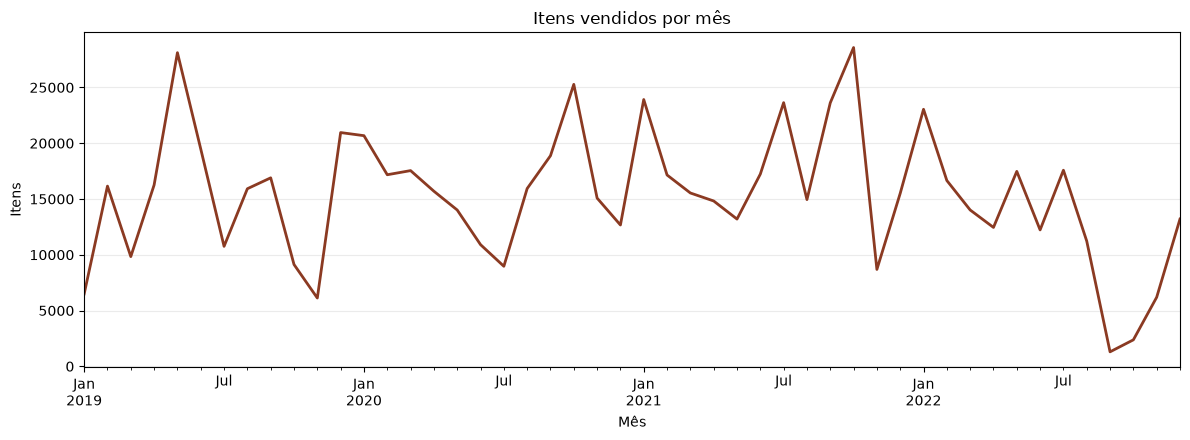

In [8]:
serie_mensal = (
    df_limpo.groupby(df_limpo["DATA"].dt.to_period("M"))
    .agg(ITENS_VENDIDOS=("PR_ID", "size"), COMPRAS_UNICAS=("CO_ID", "nunique"))
)
display(serie_mensal.tail(12))

fig, ax = plt.subplots(figsize=(12, 4.5))
serie_mensal["ITENS_VENDIDOS"].plot(ax=ax, color="#8B3A22", linewidth=2)
ax.set_title("Itens vendidos por mês")
ax.set_xlabel("Mês")
ax.set_ylabel("Itens")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 10. Comparação visual das categorias

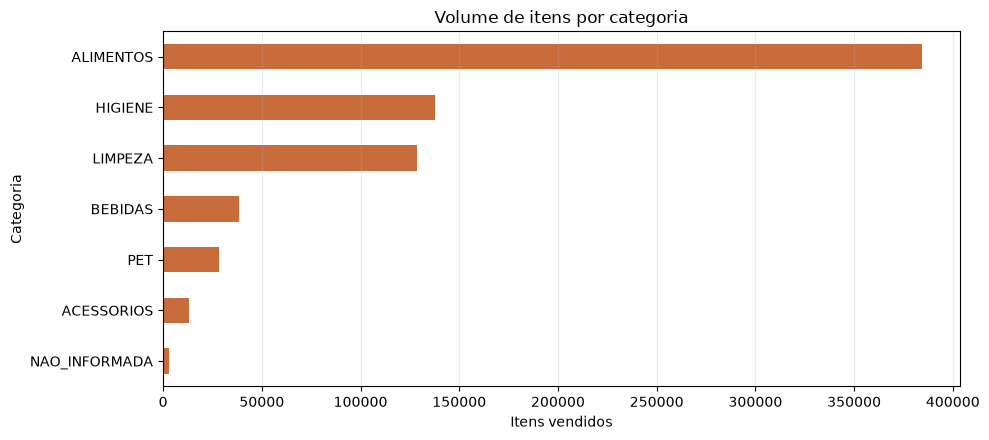

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.5))
categorias.head(7).sort_values("ITENS_VENDIDOS")["ITENS_VENDIDOS"].plot(
    kind="barh", ax=ax, color="#C96C3B"
)
ax.set_title("Volume de itens por categoria")
ax.set_xlabel("Itens vendidos")
ax.set_ylabel("Categoria")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 11. Exportação dos resultados

In [10]:
df_limpo.to_csv(PASTA_SAIDAS / "df_limpo.csv", index=False, encoding="utf-8-sig", date_format="%Y-%m-%d")
comparacao_genero.to_csv(PASTA_SAIDAS / "comparacao_genero.csv", encoding="utf-8-sig")
categorias.to_csv(PASTA_SAIDAS / "categorias.csv", encoding="utf-8-sig")
serie_mensal.to_csv(PASTA_SAIDAS / "serie_mensal.csv", encoding="utf-8-sig")
print("Arquivos atualizados em:", PASTA_SAIDAS)

Arquivos atualizados em: d:\Mini_Projeto_SCTEC\MINI_PROJETO\MiniProjeto_Ednelson_Rocha_da_Silva_Analise_de_Dados_T6\saidas


## 12. Conclusões

1. O gênero feminino possui o maior volume: **382.427 itens** e **9.615 compras únicas**.
2. **ALIMENTOS** lidera com **384.197 itens**, muito acima das demais categorias.
3. **Outubro de 2021** é o pico mensal, com **28.575 itens**.
4. Uma compra contém em média **39,71 itens**, evidenciando por que não se deve contar cada linha como compra.
5. As **96.553 duplicatas exatas** são o maior problema de qualidade encontrado; sua remoção depende da premissa documentada de duplicação de ingestão.
6. A ausência de preço/valor impede conclusões sobre receita ou ticket médio. Para análises financeiras, a fonte precisa incorporar valor unitário ou valor total.

## 13. Sprint 6 — Versionamento e entrega

O repositório público deve se chamar `Miniprojeto_Ednelson_Rocha_da_Silva_Analise_de_Dados_T6`. Consulte `PUBLICAR_NO_GITHUB.md` para os cinco commits sugeridos e a publicação pelo terminal do VS Code.